## scenario 4 = Balanced + Preprocessing + drop enhanced_casualty_severity (Penanganan imbalance & clean pipeline)


In [4]:
import pandas as pd

df = pd.read_csv('train_road_safety.csv')

df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46649 entries, 0 to 46648
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   status                              44293 non-null  object 
 1   collision_index                     46649 non-null  object 
 2   collision_year                      44261 non-null  float64
 3   collision_reference                 44343 non-null  object 
 4   vehicle_reference                   46649 non-null  float64
 5   casualty_reference                  46649 non-null  float64
 6   casualty_class                      46649 non-null  int64  
 7   sex_of_casualty                     44319 non-null  float64
 8   age_of_casualty                     46649 non-null  int64  
 9   age_band_of_casualty                46649 non-null  int64  
 10  pedestrian_location                 46649 non-null  float64
 11  pedestrian_movement                 46649

,collision_year,vehicle_reference,casualty_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_imd_decile,enhanced_casualty_severity,casualty_severity
count,44261.0,46649.000000,46649.000000,46649.000000,44319.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,46649.000000,44314.000000,46649.000000,44292.000000,46649.000000,46649.000000,46649.000000
mean,2024.0,1.455616,1.353898,1.485520,1.366637,37.102982,6.326502,0.795227,0.657442,0.196574,0.058072,0.031548,9.314112,0.993227,4.132307,1.582220,2.882741
std,0.0,1.444068,1.267332,0.732898,0.577406,19.826586,2.493991,2.196648,2.047634,0.647400,0.465305,0.286917,15.842578,0.979042,3.286280,2.273239,0.362108
min,2024.0,0.462251,0.595506,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,2024.0,1.000000,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,2.000000,-1.000000,3.000000
50%,2024.0,1.000000,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,4.000000,3.000000,3.000000
75%,2024.0,2.000000,1.000000,2.000000,2.000000,51.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,7.000000,3.000000,3.000000
max,2024.0,203.000000,202.000000,3.000000,9.000000,120.000000,11.000000,10.334651,9.000000,9.000000,9.000000,2.000000,98.000000,3.000000,10.000000,7.000000,3.000000


In [5]:
#Cek missing values

missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()


status                                2356
collision_year                        2388
collision_reference                   2306
sex_of_casualty                       2330
pedestrian_road_maintenance_worker    2335
casualty_home_area_type               2357
dtype: int64


,0
status,2356
collision_index,0
collision_year,2388
collision_reference,2306
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,2330
age_of_casualty,0
age_band_of_casualty,0


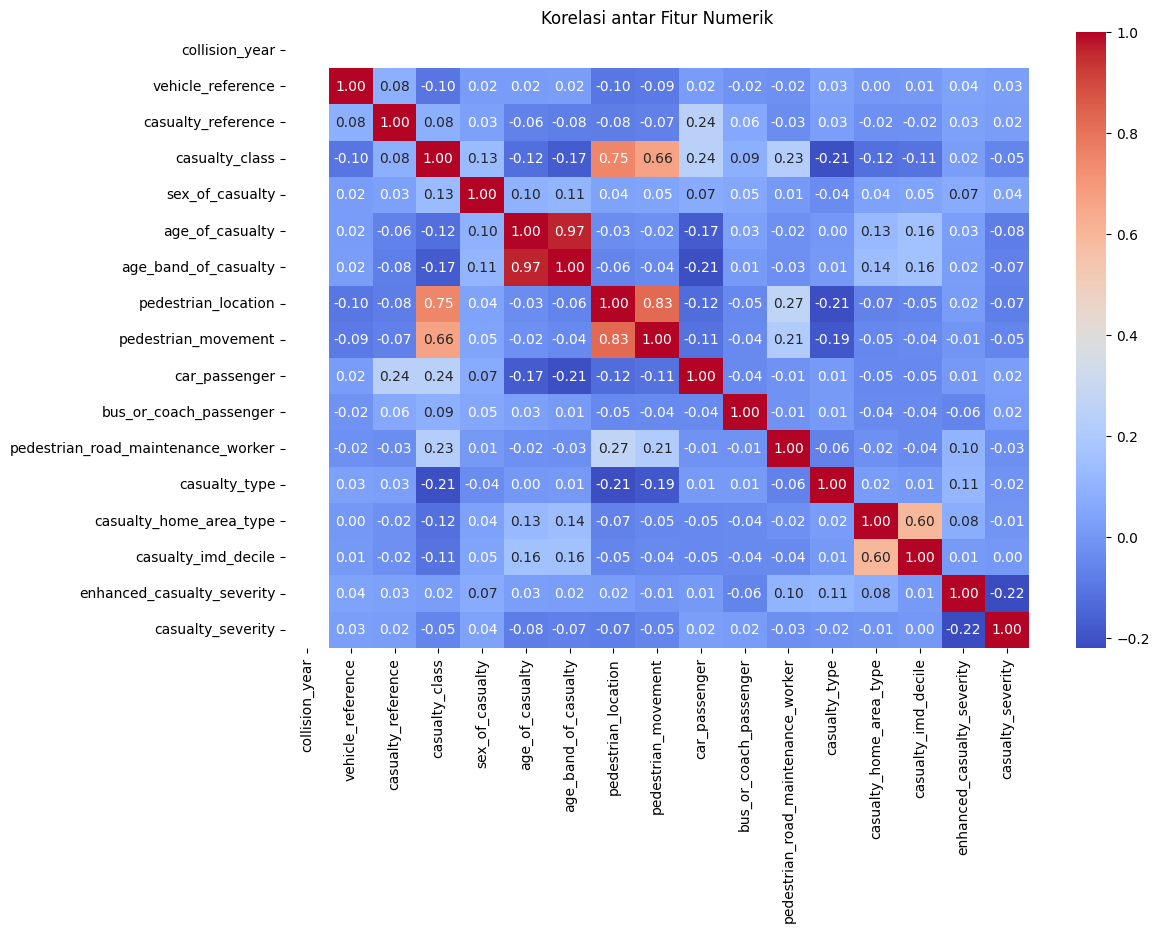

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelasi antar Fitur Numerik')
plt.show()


In [7]:
import numpy as np

df.drop(columns=["status", "collision_year", "collision_reference","lsoa_of_casualty","age_band_of_casualty","enhanced_casualty_severity","collision_index"], inplace=True)

#imputasi dengan modus
sex_mode = df["sex_of_casualty"].mode()[0]
df["sex_of_casualty"].fillna(sex_mode, inplace=True)

#imputasi dengan modus
worker_mode = df["pedestrian_road_maintenance_worker"].mode()[0]
df["pedestrian_road_maintenance_worker"].fillna(worker_mode, inplace=True)

#imputasi dengan modus
area_type_mode = df["casualty_home_area_type"].mode()[0]
df["casualty_home_area_type"].fillna(area_type_mode, inplace=True)

# Identifikasi nilai absurd
mask_invalid = df['pedestrian_location'] > 100

# Ganti nilai absurd dengan 0 atau NaN jika tidak bisa dipercaya
df.loc[mask_invalid, 'pedestrian_location'] = 0

# Set pedestrian_location = 0 bila pedestrian_movement == 0
df.loc[df['pedestrian_movement'] == 0, 'pedestrian_location'] = 0

# Gabungkan sebagai string lalu encode dan drop kolom aslinya
df['pedestrian_context'] = df['pedestrian_location'].astype(str) + "_" + df['pedestrian_movement'].astype(str)
df.drop(columns=['pedestrian_location', 'pedestrian_movement'], inplace=True)

# Ganti nilai tidak valid dengan NaN
df['casualty_home_area_type'].replace([-10, 10, 20, 30], np.nan, inplace=True)
df['casualty_imd_decile'].replace(-1, np.nan, inplace=True)

# Imputasi NaN dengan modus
home_mode = df['casualty_home_area_type'].mode()[0]
imd_mode = df['casualty_imd_decile'].mode()[0]

df['casualty_home_area_type'].fillna(home_mode, inplace=True)
df['casualty_imd_decile'].fillna(imd_mode, inplace=True)


missing = df.isnull().sum()
print(missing[missing > 0])

df.isnull().sum()

Series([], dtype: int64)


/tmp/ipython-input-7-3237322194.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["sex_of_casualty"].fillna(sex_mode, inplace=True)
/tmp/ipython-input-7-3237322194.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

,0
vehicle_reference,0
casualty_reference,0
casualty_class,0
sex_of_casualty,0
age_of_casualty,0
car_passenger,0
bus_or_coach_passenger,0
pedestrian_road_maintenance_worker,0
casualty_type,0
casualty_home_area_type,0


In [8]:
# Pisahkan fitur (X) dan target (y)
X = df.drop(columns=['casualty_severity'])
y = df['casualty_severity'] - 1  # ubah label dari [1,2,3] jadi [0,1,2]


In [9]:
categorical_features = [
    'vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty',
    'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker',
    'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile', 'pedestrian_context'
]
numerical_features = ['age_of_casualty']


In [10]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Encode
ord_enc = OrdinalEncoder()
X[categorical_features] = ord_enc.fit_transform(X[categorical_features])

# Scale
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])


casualty_severity
3    41823
2     4182
1      644
Name: count, dtype: int64
casualty_severity
3    89.654655
2     8.964822
1     1.380523
Name: proportion, dtype: float64


/tmp/ipython-input-11-3256518598.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='casualty_severity', data=df, palette='Set2')


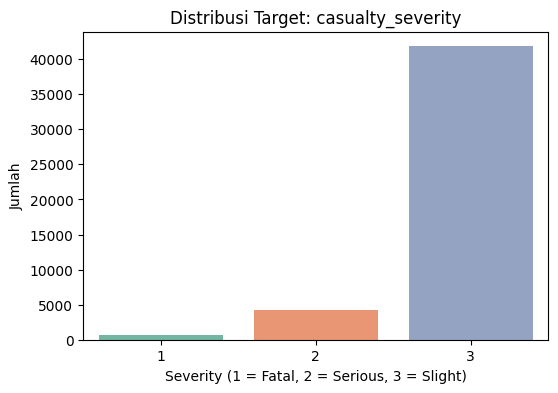

In [11]:
print(df['casualty_severity'].value_counts())

print(df['casualty_severity'].value_counts(normalize=True) * 100)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='casualty_severity', data=df, palette='Set2')
plt.title("Distribusi Target: casualty_severity")
plt.xlabel("Severity (1 = Fatal, 2 = Serious, 3 = Slight)")
plt.ylabel("Jumlah")
plt.show()



In [12]:
#split dan smote
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


casualty_severity
2    33.333333
1    33.333333
0    33.333333
Name: proportion, dtype: float64


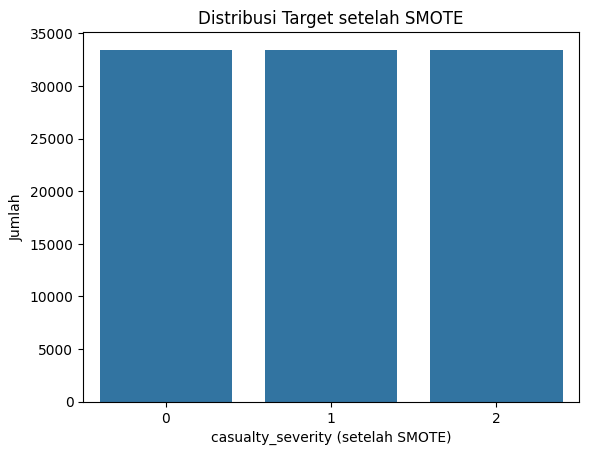

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cek distribusi setelah SMOTE
print(y_train_res.value_counts(normalize=True) * 100)

# Visualisasi
sns.countplot(x=y_train_res)
plt.title("Distribusi Target setelah SMOTE")
plt.xlabel("casualty_severity (setelah SMOTE)")
plt.ylabel("Jumlah")
plt.show()


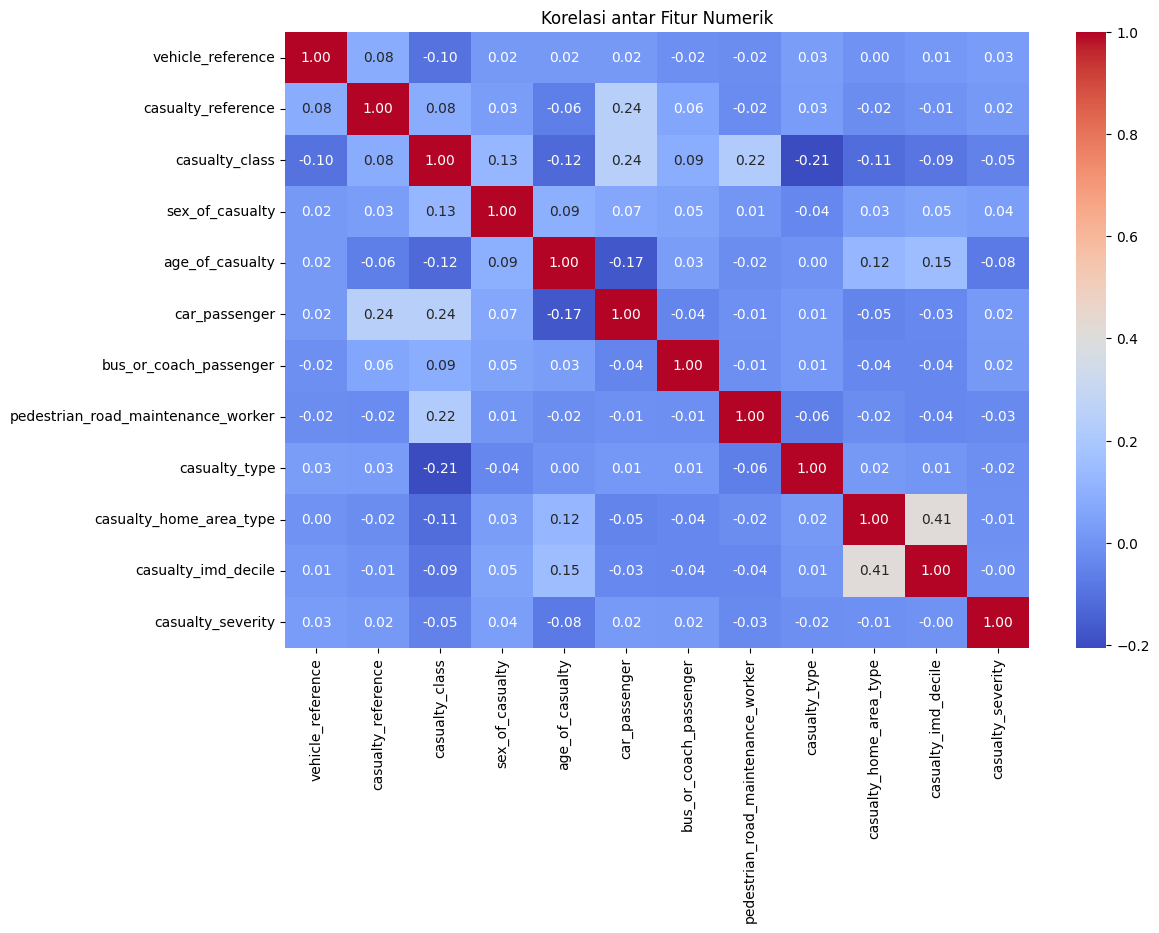

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelasi antar Fitur Numerik')
plt.show()


In [16]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier,
    BaggingClassifier, VotingClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier
import pandas as pd

# Salin data
train = df.copy()
X = train.drop(columns=['casualty_severity'])
y = train['casualty_severity'] - 1  # Encoding label

# Label encoding
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

random_state = 42
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

# Daftar semua model
classifiers = [
    ("LogisticRegression", LogisticRegression(max_iter=1000, random_state=random_state)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("GaussianNB", GaussianNB()),
    ("Decision Tree", DecisionTreeClassifier(random_state=random_state)),
    ("Random Forest", RandomForestClassifier(random_state=random_state)),
    ("ExtraTrees", ExtraTreesClassifier(random_state=random_state)),
    ("Bagging", BaggingClassifier(random_state=random_state)),
    ("AdaBoost", AdaBoostClassifier(random_state=random_state)),
    ("GradientBoost", GradientBoostingClassifier(random_state=random_state)),
    ("HistGradientBoost", HistGradientBoostingClassifier(random_state=random_state)),
    ("XGBoost", XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ("LDA", LinearDiscriminantAnalysis()),
    ("QDA", QuadraticDiscriminantAnalysis())
]

# Voting classifier
voting = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(random_state=random_state, use_label_encoder=False, eval_metric='mlogloss')),
    ('gb', GradientBoostingClassifier(random_state=random_state)),
    ('rf', RandomForestClassifier(random_state=random_state))
], voting='soft')

classifiers.append(("Voting", voting))

# Evaluasi cross-validation
cv_results = []
for name, model in classifiers:
    try:
        scores = cross_val_score(model, X_train, y_train, scoring="accuracy", cv=kfold, n_jobs=-1)
        cv_results.append((name, scores.mean(), scores.std()))
    except Exception as e:
        print(f"Model {name} gagal dievaluasi: {e}")

# Hasil evaluasi
cv_res = pd.DataFrame(cv_results, columns=["Algorithm", "CrossValMeans", "CrossValStd"])
cv_res = cv_res.sort_values(by='CrossValMeans', ascending=False)
print("Fitur yang digunakan:\n", X.columns.tolist())
print(cv_res)


Fitur yang digunakan:
 ['vehicle_reference', 'casualty_reference', 'casualty_class', 'sex_of_casualty', 'age_of_casualty', 'car_passenger', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'casualty_type', 'casualty_home_area_type', 'casualty_imd_decile', 'pedestrian_context']
             Algorithm  CrossValMeans  CrossValStd
0   LogisticRegression       0.896541     0.000052
7             AdaBoost       0.896541     0.000052
11                 LDA       0.896541     0.000052
9    HistGradientBoost       0.896299     0.000251
8        GradientBoost       0.895924     0.000294
13              Voting       0.895630     0.000477
10             XGBoost       0.893995     0.000895
1                  KNN       0.886841     0.001477
4        Random Forest       0.875586     0.001358
6              Bagging       0.857606     0.002107
5           ExtraTrees       0.856320     0.001945
2           GaussianNB       0.831025     0.020545
3        Decision Tree       0.811651     0.

In [18]:
!pip install optuna

import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Gunakan StratifiedKFold yang sama
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# === AdaBoost ===
def objective_ada(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 2.0)
    }
    model = AdaBoostClassifier(random_state=42, **params)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_ada = optuna.create_study(direction="maximize")
study_ada.optimize(objective_ada, n_trials=30)

# === LDA ===
def objective_lda(trial):
    solver = trial.suggest_categorical("solver", ["svd", "lsqr", "eigen"])
    shrinkage = None
    if solver in ["lsqr", "eigen"]:
        shrinkage = trial.suggest_categorical("shrinkage", ["auto", 0.0, 0.1, 0.5, 1.0])

    params = {"solver": solver}
    if shrinkage is not None:
        params["shrinkage"] = shrinkage

    model = LinearDiscriminantAnalysis(**params)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_lda = optuna.create_study(direction="maximize")
study_lda.optimize(objective_lda, n_trials=30)

# === Logistic Regression ===
def objective_logreg(trial):
    params = {
        "C": trial.suggest_float("C", 0.001, 10.0, log=True),
        "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs"]),
        "penalty": "l2"
    }
    model = LogisticRegression(**params, max_iter=1000, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy').mean()

study_logreg = optuna.create_study(direction="maximize")
study_logreg.optimize(objective_logreg, n_trials=30)

print("=== Best AdaBoost Hyperparameters ===")
print(study_ada.best_params)
print("Best AdaBoost Accuracy:", study_ada.best_value)

print("\n=== Best LDA Hyperparameters ===")
print(study_lda.best_params)
print("Best LDA Accuracy:", study_lda.best_value)

print("\n=== Best Logistic Regression Hyperparameters ===")
print(study_logreg.best_params)
print("Best Logistic Regression Accuracy:", study_logreg.best_value)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 17.3 MB/s eta 0:00:00


[I 2025-06-20 12:23:32,008] A new study created in memory with name: no-name-c3fb0327-3d7c-49b4-83a1-77a797491177
[I 2025-06-20 12:23:53,602] Trial 0 finished with value: 0.896540636558002 and parameters: {'n_estimators': 284, 'learning_rate': 0.416573854476897}. Best is trial 0 with value: 0.896540636558002.
[I 2025-06-20 12:24:02,580] Trial 1 finished with value: 0.896540636558002 and parameters: {'n_estimators': 106, 'learning_rate': 0.1976931969560912}. Best is trial 0 with value: 0.896540636558002.
[I 2025-06-20 12:24:16,578] Trial 2 finished with value: 0.8965138340931376 and parameters: {'n_estimators': 175, 'learning_rate': 1.852840665171822}. Best is trial 0 with value: 0.896540636558002.
[I 2025-06-20 12:24:25,557] Trial 3 finished with value: 0.896540636558002 and parameters: {'n_estimators': 106, 'learning_rate': 0.4098731054088488}. Best is trial 0 with value: 0.896540636558002.
[I 2025-06-20 12:24:44,840] Trial 4 finished with value: 0.896540636558002 and parameters: {'n_

=== Best AdaBoost Hyperparameters ===
{'n_estimators': 284, 'learning_rate': 0.416573854476897}
Best AdaBoost Accuracy: 0.896540636558002

=== Best LDA Hyperparameters ===
{'solver': 'svd'}
Best LDA Accuracy: 0.896540636558002

=== Best Logistic Regression Hyperparameters ===
{'C': 0.19013629268094298, 'solver': 'lbfgs'}
Best Logistic Regression Accuracy: 0.896540636558002


In [19]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# === Model 1: AdaBoost ===
ada_best = AdaBoostClassifier(
    n_estimators=284,
    learning_rate=0.416573854476897,
    random_state=42
)
ada_best.fit(X_train, y_train)
y_pred_ada = ada_best.predict(X_test)

print("=== AdaBoost ===")
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

# === Model 2: LDA ===
lda_best = LinearDiscriminantAnalysis(
    solver='svd'
)
lda_best.fit(X_train, y_train)
y_pred_lda = lda_best.predict(X_test)

print("\n=== LDA ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lda))
print(classification_report(y_test, y_pred_lda))

# === Model 3: Logistic Regression ===
logreg_best = LogisticRegression(
    C=0.19013629268094298,
    solver='lbfgs',
    penalty='l2',
    max_iter=1000,
    random_state=42
)
logreg_best.fit(X_train, y_train)
y_pred_log = logreg_best.predict(X_test)

print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


=== AdaBoost ===
Accuracy: 0.8965702036441586
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.00      0.00      0.00       836
           2       0.90      1.00      0.95      8365

    accuracy                           0.90      9330
   macro avg       0.30      0.33      0.32      9330
weighted avg       0.80      0.90      0.85      9330


=== LDA ===
Accuracy: 0.8965702036441586
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.00      0.00      0.00       836
           2       0.90      1.00      0.95      8365

    accuracy                           0.90      9330
   macro avg       0.30      0.33      0.32      9330
weighted avg       0.80      0.90      0.85      9330



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m


=== Logistic Regression ===
Accuracy: 0.8965702036441586
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       129
           1       0.00      0.00      0.00       836
           2       0.90      1.00      0.95      8365

    accuracy                           0.90      9330
   macro avg       0.30      0.33      0.32      9330
weighted avg       0.80      0.90      0.85      9330



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre